In [1]:
import whisper

model = whisper.load_model("small")
result = model.transcribe(".\학교폭력_SAMPLE.mp3")

c:\Users\smhrd\AppData\Local\Programs\Python\Python39\lib\site-packages\whisper\transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


In [2]:
textlist = []
for i in result:
    if i == 'segments':
        for j in result[i]:
            if j['text'] not in textlist:
                textlist.append(j['text'])
print(textlist)

[' 너는 맞으면 아프고 나는 맞으면 안 아파?', ' 아프겠지 아프니까', ' 나는 어렸으니까 너무나', ' 그때도 어렸으니까 내가 철 없다고 했잖아', ' 그러니까 내가 사과를 하는 거잖아', ' 그니까 그 사과가 왜 말로 틈 치고 마냐고', ' 그때도 나도 어렸으니까', ' 내가 나이 먹고 내가 그렇게 했니?', ' 나도 그때로 철이 없었으니까', ' 그때로 한 거잖아', ' 친구 때리면 안 된다는 거는', ' 초등학교 1학년 때부터 배우는 거야', ' 발음새만 어쩌고 그런 거에서', ' 친구 놀리지 말라는 건 유치원에서 배우는 거고', ' 나도 한번 물어보자', ' 너는 나를 그렇게 왜 때렸냐?', ' 나도 그때 철이 없었으니까', ' 나도 모르겠다', ' 철이 없었다 이런 얘기 말고', ' 나도 모르지', ' 내가 왜 그때 내가 왜 그렇게 때렸는지', ' 나도 몰라']


In [3]:
# f = open('./childTalk.txt', 'w', encoding='utf-8')
# for i in textlist:
#     f.write(i)
#     f.write('\n')
# f.close()

In [4]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import TextClassificationPipeline
import matplotlib.pyplot as plt
%matplotlib inline

c:\Users\smhrd\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# f = open('./childTalk.txt', 'r', encoding='utf-8')
# temp = f.readlines()
# lines = []
# for line in temp:
#     lines.append(line.strip())
# f.close()
# 
# df = pd.DataFrame(lines, columns = ['Message'])
# print(df.head())

In [6]:
df = pd.DataFrame(textlist, columns = ['Message'])
print(df.head())

                    Message
0   너는 맞으면 아프고 나는 맞으면 안 아파?
1                 아프겠지 아프니까
2              나는 어렸으니까 너무나
3    그때도 어렸으니까 내가 철 없다고 했잖아
4        그러니까 내가 사과를 하는 거잖아


### KcELECTRA-base-v2022

In [16]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification


tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base-v2022")
model = AutoModelForSequenceClassification.from_pretrained("beomi/KcELECTRA-base-v2022")

# 구버전(v2021)을 사용하기 원하실 경우
#tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base")
#model = AutoModel.from_pretrained("beomi/KcELECTRA-base")

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base-v2022 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## KcBert-base

In [7]:
# BERT 모델과 토크나이저 불러오기
model_name = "beomi/kcbert-base"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at beomi/kcbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## KcBert-Large

In [22]:
# BERT 모델과 토크나이저 불러오기
model_name = "beomi/kcbert-large"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

c:\Users\smhrd\AppData\Local\Programs\Python\Python39\lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\smhrd\.cache\huggingface\hub\models--beomi--kcbert-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at 

## KoBert

In [ ]:
# BERT 모델과 토크나이저 불러오기
from transformers import BertModel, XLNetTokenizer
from kobert_tokenizer import KoBERTTokenizer
tokenizer = KoBERTTokenizer.from_pretrained('skt/kobert-base-v1')
model = BertModel.from_pretrained('skt/kobert-base-v1')

In [23]:
# 파이프라인 생성
pipeline = TextClassificationPipeline(model=model, tokenizer=tokenizer, return_all_scores=True)

Device set to use cpu
c:\Users\smhrd\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [24]:
# 감정 분석 수행
def sentiment_analysis(message):
    results = pipeline(message)
    positive_score = results[0][1]['score']
    negative_score = results[0][0]['score']
    return positive_score, negative_score
    
# 대화 내용에 대해 감정 분석 수행
df['Positive'], df['Negative'] = zip(*df['Message'].map(sentiment_analysis))

In [25]:
print(df)

                       Message  Positive  Negative
0      너는 맞으면 아프고 나는 맞으면 안 아파?  0.372114  0.627886
1                    아프겠지 아프니까  0.405007  0.594993
2                 나는 어렸으니까 너무나  0.293587  0.706413
3       그때도 어렸으니까 내가 철 없다고 했잖아  0.239987  0.760013
4           그러니까 내가 사과를 하는 거잖아  0.319239  0.680761
5      그니까 그 사과가 왜 말로 틈 치고 마냐고  0.342278  0.657722
6                 그때도 나도 어렸으니까  0.312321  0.687679
7          내가 나이 먹고 내가 그렇게 했니?  0.316917  0.683083
8              나도 그때로 철이 없었으니까  0.331167  0.668833
9                    그때로 한 거잖아  0.223348  0.776652
10             친구 때리면 안 된다는 거는  0.367599  0.632401
11         초등학교 1학년 때부터 배우는 거야  0.260584  0.739416
12             발음새만 어쩌고 그런 거에서  0.401790  0.598210
13   친구 놀리지 말라는 건 유치원에서 배우는 거고  0.234407  0.765593
14                  나도 한번 물어보자  0.221501  0.778499
15            너는 나를 그렇게 왜 때렸냐?  0.283938  0.716061
16              나도 그때 철이 없었으니까  0.248789  0.751211
17                     나도 모르겠다  0.297581  0.702419
18             철이 없었다 이런 얘기 말고 

In [26]:
print(df['Positive'].mean())
print(df['Negative'].mean())

0.3060860518704761
0.6939139555801045


Text(0.5, 1.0, 'Average Sentiment Scores')

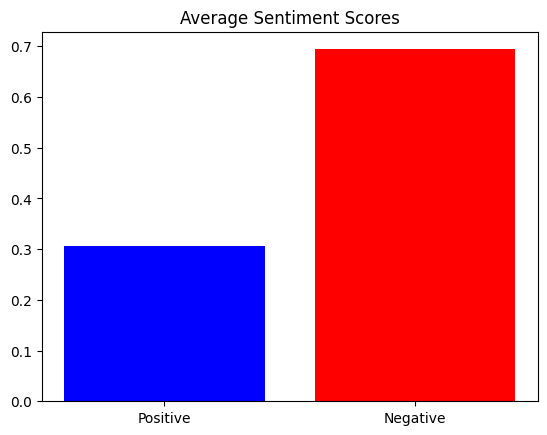

In [27]:
plt.bar(['Positive', 'Negative'], [df['Positive'].mean(), df['Negative'].mean()], color=['blue', 'red'])
plt.title('Average Sentiment Scores')